# Preprocessing

In [1]:
import os
import sys
import tqdm
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
import torchvision.utils as vutils
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
sys.path.append(os.path.abspath('../../src/dataset'))
from paired_image_dataset import PairedImageDataset

DATA_DIR = os.path.join('..', '..', 'data')
print(os.listdir(DATA_DIR))

['all', 'cnn', 'low_light']


In [3]:
image_width = 256
image_height = 128
batch_size = 32
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

In [20]:
train_transform = T.Compose([
    T.Resize((image_height, image_width)),
    T.ToTensor(),
    T.Normalize(*stats)])

valid_transform = T.Compose([
    T.Resize((image_height, image_width)),
    T.ToTensor(),
    T.Normalize(*stats)
])

In [22]:
train_ds = PairedImageDataset(blur_dir=os.path.join(DATA_DIR, 'low_light', 'train', 'low_light'), 
                              normal_dir=os.path.join(DATA_DIR, 'low_light', 'train', 'enhanced'),
                              transform=train_transform)

valid_ds = PairedImageDataset(blur_dir=os.path.join(DATA_DIR, 'low_light', 'valid', 'low_light'), 
                              normal_dir=os.path.join(DATA_DIR, 'low_light', 'valid', 'enhanced'),
                              transform=valid_transform)

In [24]:
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
valid_dl = DataLoader(valid_ds, batch_size=32*2, shuffle=True, num_workers=4)

### Helper functions

In [27]:
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

def show_images(images, nmax=16):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    denorm_imgs = denorm(images.detach()[:nmax])
    ax.imshow(make_grid(denorm_imgs, nrow=8).permute(1, 2, 0))

def show_batch(dl, nmax=16):
    for images, _ in dl:
        show_images(images, nmax)
        break

In [81]:
def show_paired_samples(dataset, num_samples=4):
    fig, axes = plt.subplots(num_samples, 2, figsize=(5, 2 * num_samples))

    for i in range(num_samples):
        input_img, target_img = dataset[i]

        input_img = denorm(input_img)
        target_img = denorm(target_img)

        if isinstance(input_img, torch.Tensor):
            input_img = input_img.permute(1, 2, 0).numpy()
            target_img = target_img.permute(1, 2, 0).numpy()

        axes[i, 0].imshow(input_img)
        axes[i, 0].set_title("Low Light (Input)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(target_img)
        axes[i, 1].set_title("Normal (Target)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

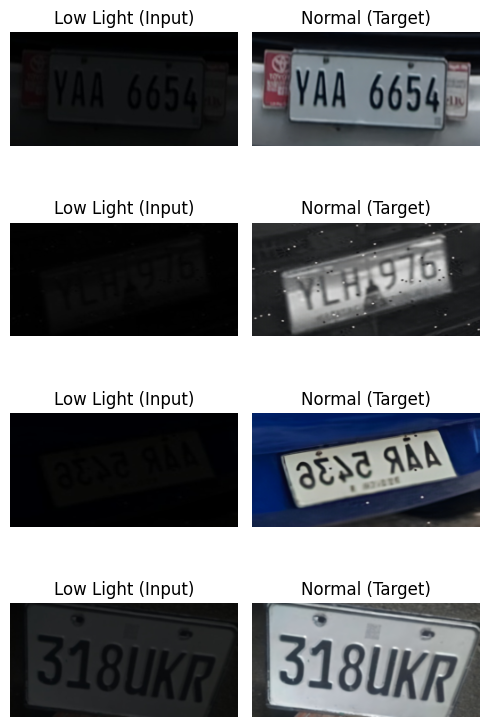

In [83]:
show_paired_samples(train_ds)

### Setup GPU

In [72]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

In [74]:
device = get_default_device()
device

device(type='cuda')

In [76]:
train_dl = DeviceDataLoader(train_dl, device)

# Building the Model

In [14]:
class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4):
        super(DownSample, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, 
                      stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=4):
        super(UpSample, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, 
                               stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

### Generator

In [16]:
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(Generator, self).__init__()

        # Encoder (Downsampling)
        self.down1 = DownSample(in_channels, 64)  # -> (64, 64, 128)
        self.down2 = DownSample(64, 128)          # -> (128, 32, 64)
        self.down3 = DownSample(128, 256)         # -> (256, 16, 32)
        self.down4 = DownSample(256, 512)         # -> (512, 8, 16)
        self.down5 = DownSample(512, 1024)        # -> (1024, 4, 8)
        self.down6 = DownSample(1024, 1024)       # -> (1024, 2, 4)
        self.down7 = DownSample(1024, 1024)       # -> (1024, 1, 2)

        # Decoder (Upsampling)
        self.up1 = UpSample(1024, 1024)           # -> (1024, 2, 4)
        self.up2 = UpSample(2048, 1024)           # -> (1024, 4, 8)
        self.up3 = UpSample(2048, 512)            # -> (512, 8, 16)
        self.up4 = UpSample(1024, 256)            # -> (256, 16, 32)
        self.up5 = UpSample(512, 128)             # -> (128, 32, 64)
        self.up6 = UpSample(256, 64)              # -> (64, 64, 128)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1), # -> (64, 128, 256)
            nn.Tanh()
        )

    def forward(self, x):
        # U-Net generator with skip connections from encoder to decoder
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        
        u1 = self.up1(d7, d6)
        u2 = self.up2(u1, d5)
        u3 = self.up3(u2, d4)
        u4 = self.up4(u3, d3)
        u5 = self.up5(u4, d2)
        u6 = self.up6(u5, d1)
        u7 = self.final(u6)
        return u7

In [18]:
image = torch.rand((1, 3, 128, 256))
out_channels = 3
generator = Generator()
output = generator(image)
print(output.shape)

torch.Size([1, 3, 128, 256])


### Discriminator

In [20]:
def conv_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=bias),
        nn.LeakyReLU(0.2, inplace=True)
    )

In [22]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=6, kernel_size=4):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            conv_block(in_channels, 64), # 128x256
            conv_block(64, 128), # 64x128
            conv_block(128, 256), # 32x64
            conv_block(256, 512), # 16x32
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1, bias=False) # 8x16
        )

    def forward(self, image1, image2):
        img_input = torch.cat((image1, image2), 1)
        return self.model(img_input)

In [24]:
image1 = torch.rand((1, 3, 128, 256))
image2 = torch.rand((1, 3, 128, 256))

out_channels = 3
discriminator = Discriminator()
output = discriminator(image1, image2)
print(output.shape)

torch.Size([1, 1, 8, 16])


# Training

In [78]:
discriminator = to_device(discriminator, device)
generator = to_device(generator, device)

### Defining loss functions

In [37]:
comparison_loss = nn.BCEWithLogitsLoss()
L1_loss = nn.L1Loss()

### Discriminator training function

In [109]:
def train_discriminator(inputs, targets, opt_d):
    # Clear discriminator gradients
    opt_d.zero_grad()

    # Pass real image
    real_preds = discriminator(inputs, targets)
    real_targets = torch.ones(inputs.size(0), 1, device=device)
    real_loss = comparison_loss(real_preds, real_targets)
    real_score = torch.mean(real_preds).item()

    # Generate fake image
    fake_image = generator(inputs).detach()
    fake_preds = discriminator(inputs, fake_image)
    fake_label = torch.zeros(fake_preds.size(0), 1, device=device)
    fake_loss = comparison_loss(fake_preds, fake_label)
    fake_score = torch.mean(fake_preds).item()

    # Total loss
    loss = (real_loss + fake_loss) / 2

    # Update discriminator weights
    loss.backward()
    opt_d.step()

    return loss, real_score, fake_score

### Generator training function

In [111]:
def train_generator(inputs, targets, opt_g, L1_lambda):
    # Clear generator gradients
    opt_g.zero_grad()

    # Generate image
    gen_image = generator(inputs)
    d_output = discriminator(inputs, gen_image)
    desired_output = torch.ones(inputs.size(0), 1, device=device)

    # Update generator weights
    loss = comparison_loss(d_output, desired_output) + L1_lambda * L1_loss
    loss.backward()
    opt_g.step()

    return loss, gen_image

### Hyperparameter configurations

In [114]:
L1_lambda = 100
epochs = 10
lr = 0.0002
beta1 = 0.5
beta2 = 0.999

In [ ]:
def fit(epochs, lr, start_idx=11):
    torch.cuda.empty_cache()

    # Losses and scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []

    # Create optimizers
    opt_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
    opt_g = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))

    # Train
    for epoch in range(epochs):
        for images, _ in tqdm(train_dl):
            
            # Splitting the image
            inputs = images[:,:,:,:256].to(device)
            targets = images[:,:,:,:256].to(device)

            # Train discriminator
            loss_d, real_score, fake_score = train_discriminator(inputs, targets, opt_d)

            # Train generator
            

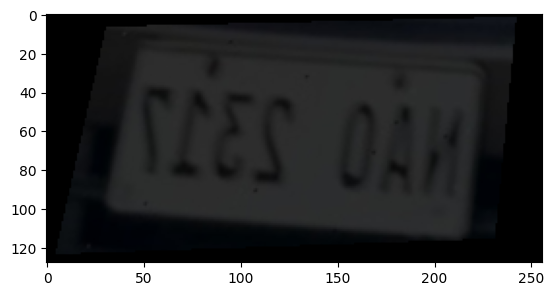

In [120]:
Normalization_Values = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
def DeNormalize(tensor_of_image):
    return tensor_of_image * Normalization_Values[1][0] + Normalization_Values[0][0]

images,_ = next(iter(train_dl))

plt.imshow(DeNormalize(images[5]).cpu().permute(1,2,0))
plt.show()